In [ ]:
import math as mh
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import copy
import random
import plotly.express as px
import matplotlib.animation as animation
import matplotlib.patches as patches
from IPython.display import Image

from ipywidgets import IntProgress
from IPython.display import display

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Stock data class

In [ ]:
from datetime import datetime
class StockConverter:
  def __init__(self):
    self.data_name = 'Дата'
    self.price_name = 'Цена'
    self.dataframe = pd.DataFrame({self.data_name : []})


  def add_data(self, path: str):
    df = pd.read_csv(path)
    self.dataframe[self.data_name] = df[self.data_name]
    self.dataframe[self.data_name] = pd.to_datetime(self.dataframe[self.data_name], format='%d.%m.%Y')

  @property
  def get_date(self):
    return self.dataframe[self.data_name]

  def add_price(self, path: str, stock_name: str):
    df = pd.read_csv(path)
    self.dataframe[stock_name] = df[self.price_name]
    self.dataframe[stock_name] = self.dataframe[stock_name].str.replace('.', '', regex=False)
    self.dataframe[stock_name] = self.dataframe[stock_name].str.replace(',', '.', regex=False)
    self.dataframe[stock_name] = self.dataframe[stock_name].astype(float)

  def build(self):
    self.dataframe = self.dataframe.set_index(self.data_name)
    self.dataframe.sort_values(by=[self.data_name], inplace=True)


### Поиск хорошо коррелирующих данных

In [ ]:
gazprom_path_train, gazprom_name= '/content/drive/MyDrive/Sem7/Math/Lab5/01.04.2020_01.04.2024_GAZP.csv', "Газпром"
lukoil_path_train, lukoil_name = '/content/drive/MyDrive/Sem7/Math/Lab5/01.04.2020_01.04.2024_LKOH.csv', "Лукоил"
tatneft_path_train, tatneft_name = '/content/drive/MyDrive/Sem7/Math/Lab5/01.04.2020_01.04.2024_TATN.csv', "Татнефть"
surgutn_path_train, surgutn_name = '/content/drive/MyDrive/Sem7/Math/Lab5/01.04.2020_01.04.2024_SNGS.csv', "Сургутнефтегаз"

gazprom_path_test = '/content/drive/MyDrive/Sem7/Math/Lab5/02.04.2024_08.12.2024_GAZP.csv', "Газпром"
lukoil_path_test = '/content/drive/MyDrive/Sem7/Math/Lab5/02.04.2024_08.12.2024_LKOH.csv', "Лукоил"
tatneft_path_test = '/content/drive/MyDrive/Sem7/Math/Lab5/02.04.2024_08.12.2024_TATN.csv', "Татнефть"
surgutn_path_test = '/content/drive/MyDrive/Sem7/Math/Lab5/02.04.2024_08.12.2024_SNGS.csv', "Сургутнефтегаз"

In [ ]:
sc = StockConverter()
sc.add_data(gazprom_path_train)
sc.add_price(gazprom_path_train, gazprom_name)
sc.add_price(lukoil_path_train, lukoil_name)
sc.add_price(tatneft_path_train, tatneft_name)
sc.add_price(surgutn_path_train, surgutn_name)
sc.build()

In [ ]:
sc.dataframe

,Газпром,Лукоил,Татнефть,Сургутнефтегаз
Дата,,,,
2020-04-01,180.06,4674.5,544.0,35.000
2020-04-02,187.04,5050.0,585.0,35.670
2020-04-03,189.77,5204.5,600.6,36.385
2020-04-06,191.10,5163.0,608.9,37.250
2020-04-07,191.22,5118.0,583.6,37.200
...,...,...,...,...
2024-03-26,157.94,7419.0,692.8,29.070
2024-03-27,157.79,7493.0,689.4,29.320
2024-03-28,157.05,7481.0,687.9,29.170


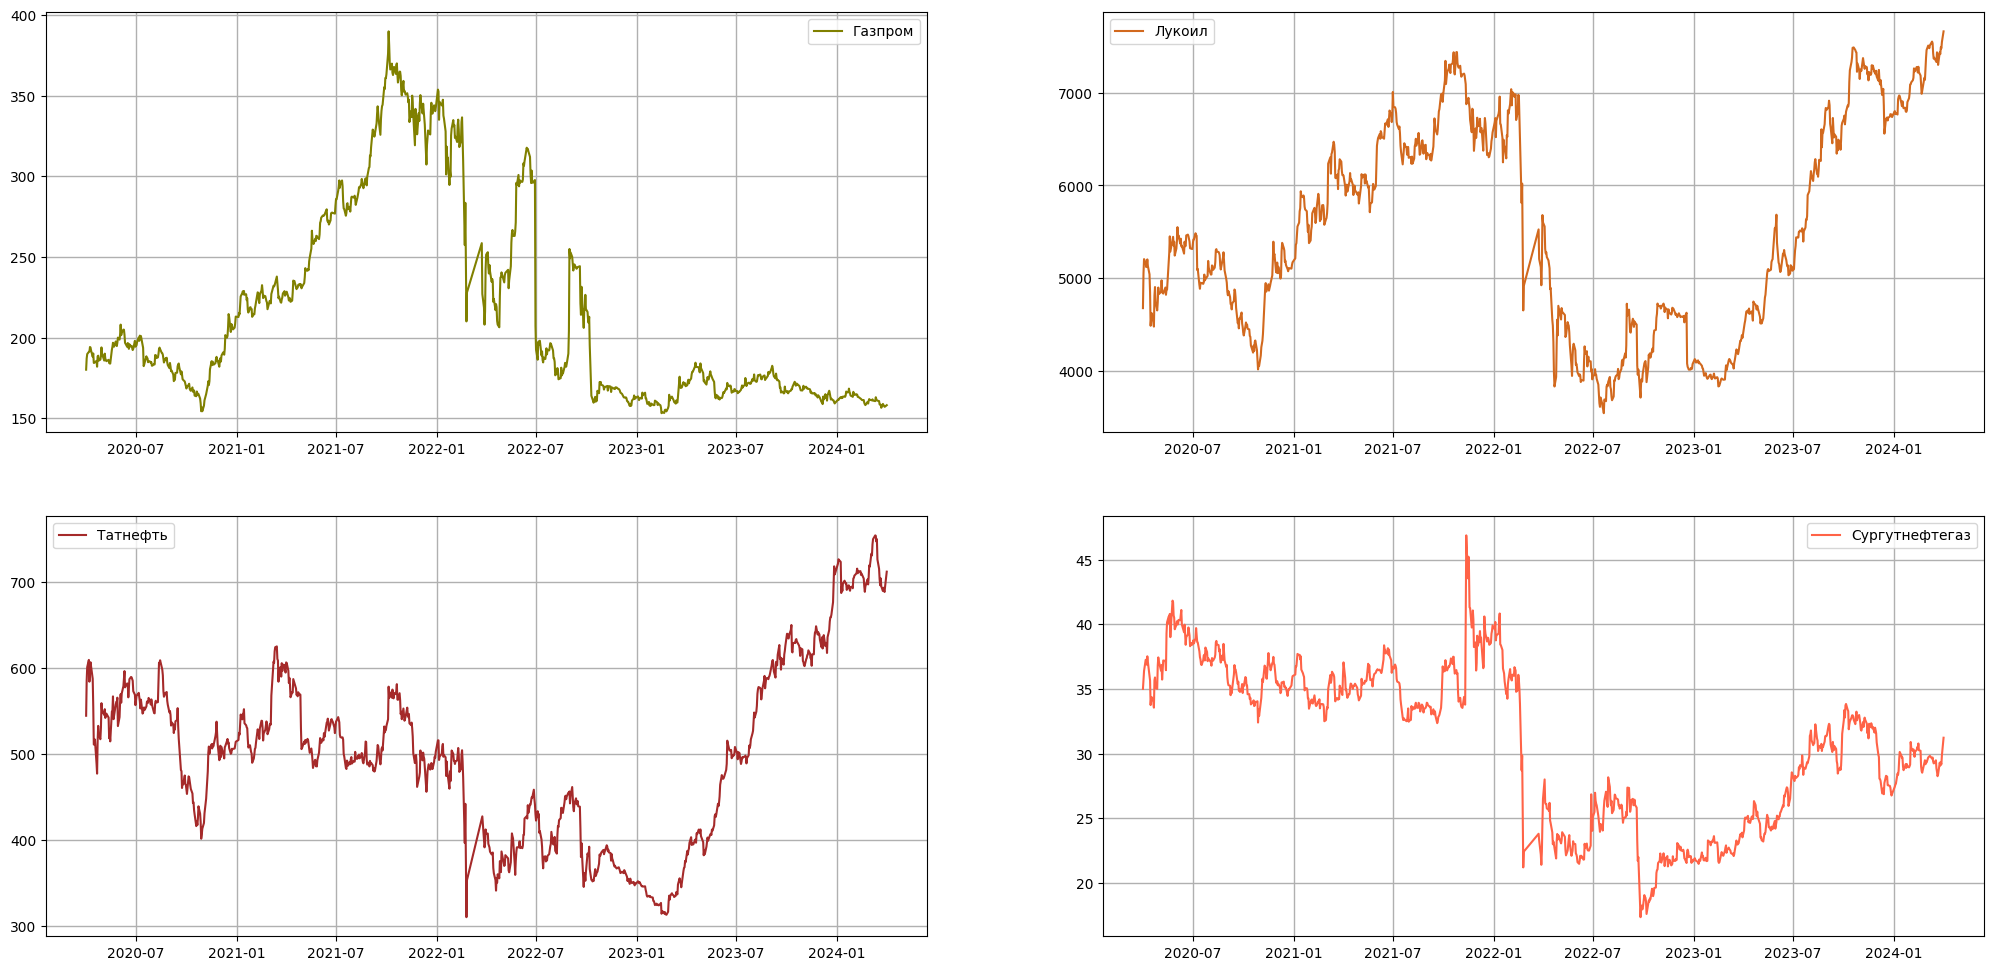

In [ ]:
fig = plt.figure(figsize=(25, 12))
ax = fig.subplots(2,2)

ax[0][0].plot(sc.dataframe[gazprom_name], color="olive", label="Газпром")
ax[0][0].grid(True, which='both', linewidth=1)
ax[0][0].legend()

ax[0][1].plot(sc.dataframe[lukoil_name], color="chocolate", label="Лукоил")
ax[0][1].grid(True, which='both', linewidth=1)
ax[0][1].legend()

ax[1][0].plot(sc.dataframe[tatneft_name], color="brown", label="Татнефть")
ax[1][0].grid(True, which='both', linewidth=1)
ax[1][0].legend()

ax[1][1].plot(sc.dataframe[surgutn_name], color="tomato", label="Сургутнефтегаз")
ax[1][1].grid(True, which='both', linewidth=1)
ax[1][1].legend()

In [ ]:
corr = sc.dataframe.corr()
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
corr[mask] = np.nan
(corr
 .style
 .background_gradient(cmap='coolwarm', axis=None, vmin=-1, vmax=1)
 .highlight_null(color='#f1f1f1')
 .format(precision=2))

,Газпром,Лукоил,Татнефть,Сургутнефтегаз
Газпром,nan,nan,nan,nan
Лукоил,0.35,nan,nan,nan
Татнефть,-0.02,0.79,nan,nan
Сургутнефтегаз,0.40,0.53,0.57,nan


### Ряды с хорошей корреляцией

Unity Software Inc - американская компания разрабатывающая програмное обеспечение для игр


Wayfair Inc - американская компания электронной коммерции, которая продает мебель и товары для дома онлайн.

In [ ]:
u_path_train, u= '/content/drive/MyDrive/Sem7/Math/Lab5/train_Unity.csv', "U"
w_path_train, w = '/content/drive/MyDrive/Sem7/Math/Lab5/train_Wayfair.csv', "W"

train_data = StockConverter()
train_data.add_data(u_path_train)
train_data.add_price(u_path_train, u)
train_data.add_price(w_path_train, w)
train_data.build()
print(f"Коэффициент корреляции:{train_data.dataframe[u].corr(train_data.dataframe[w])}")

Коэффициент корреляции:0.9743986582906424


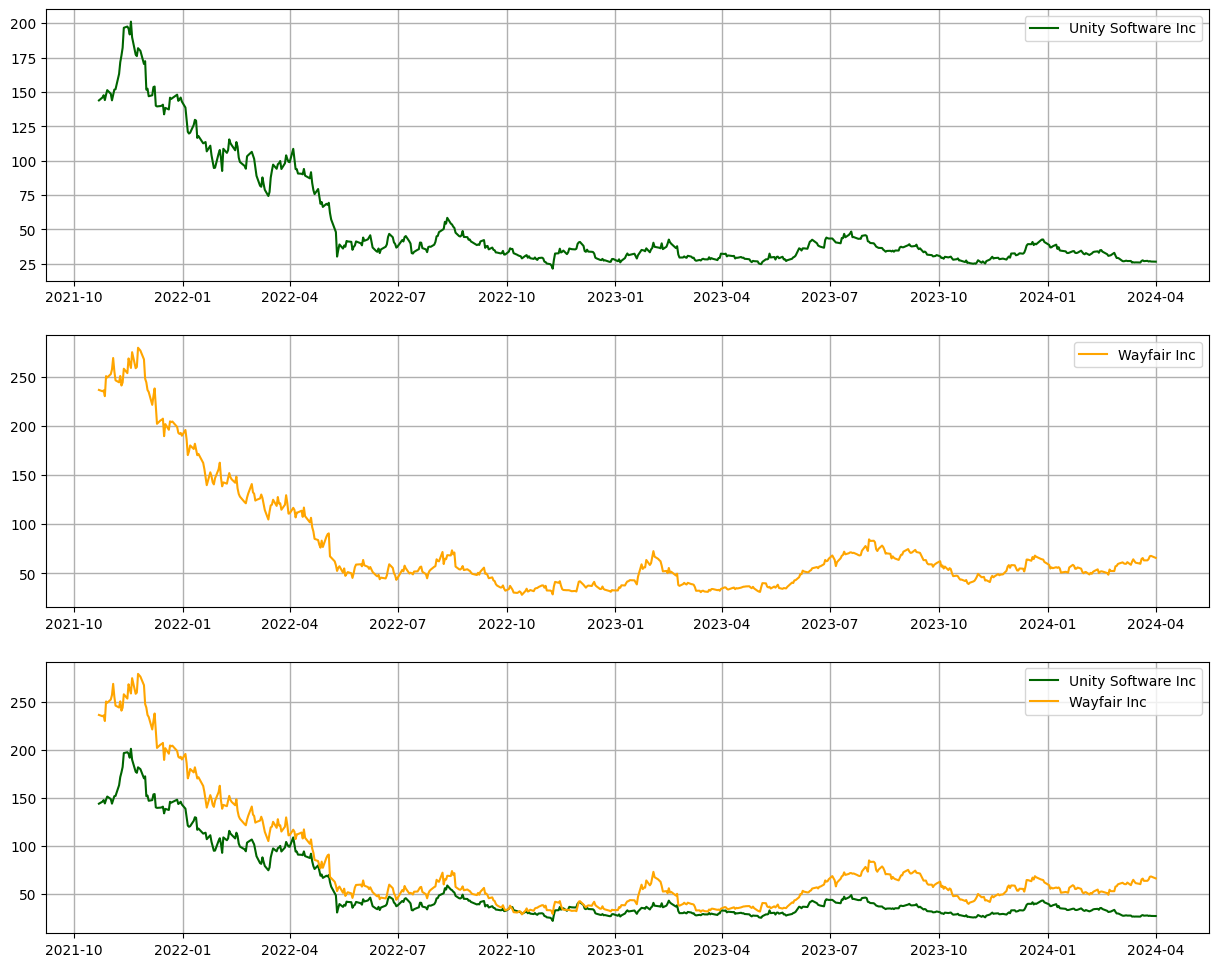

In [ ]:
fig = plt.figure(figsize=(15, 12))
ax = fig.subplots(3,1)

ax[0].plot(train_data.dataframe[u], color="darkgreen", label="Unity Software Inc")
ax[0].grid(True, which='both', linewidth=1)
ax[0].legend()

ax[1].plot(train_data.dataframe[w], color="orange", label="Wayfair Inc")
ax[1].grid(True, which='both', linewidth=1)
ax[1].legend()

ax[2].plot(train_data.dataframe[u], color="darkgreen", label="Unity Software Inc")
ax[2].plot(train_data.dataframe[w], color="orange", label="Wayfair Inc")
ax[2].grid(True, which='both', linewidth=1)
ax[2].legend()

#### Тестовая выборка

In [ ]:
u_path_test = '/content/drive/MyDrive/Sem7/Math/Lab5/test_U.csv'
w_path_test = '/content/drive/MyDrive/Sem7/Math/Lab5/test_W.csv'

test_data = StockConverter()
test_data.add_data(u_path_test)
test_data.add_price(u_path_test, u)
test_data.add_price(w_path_test, w)
test_data.build()

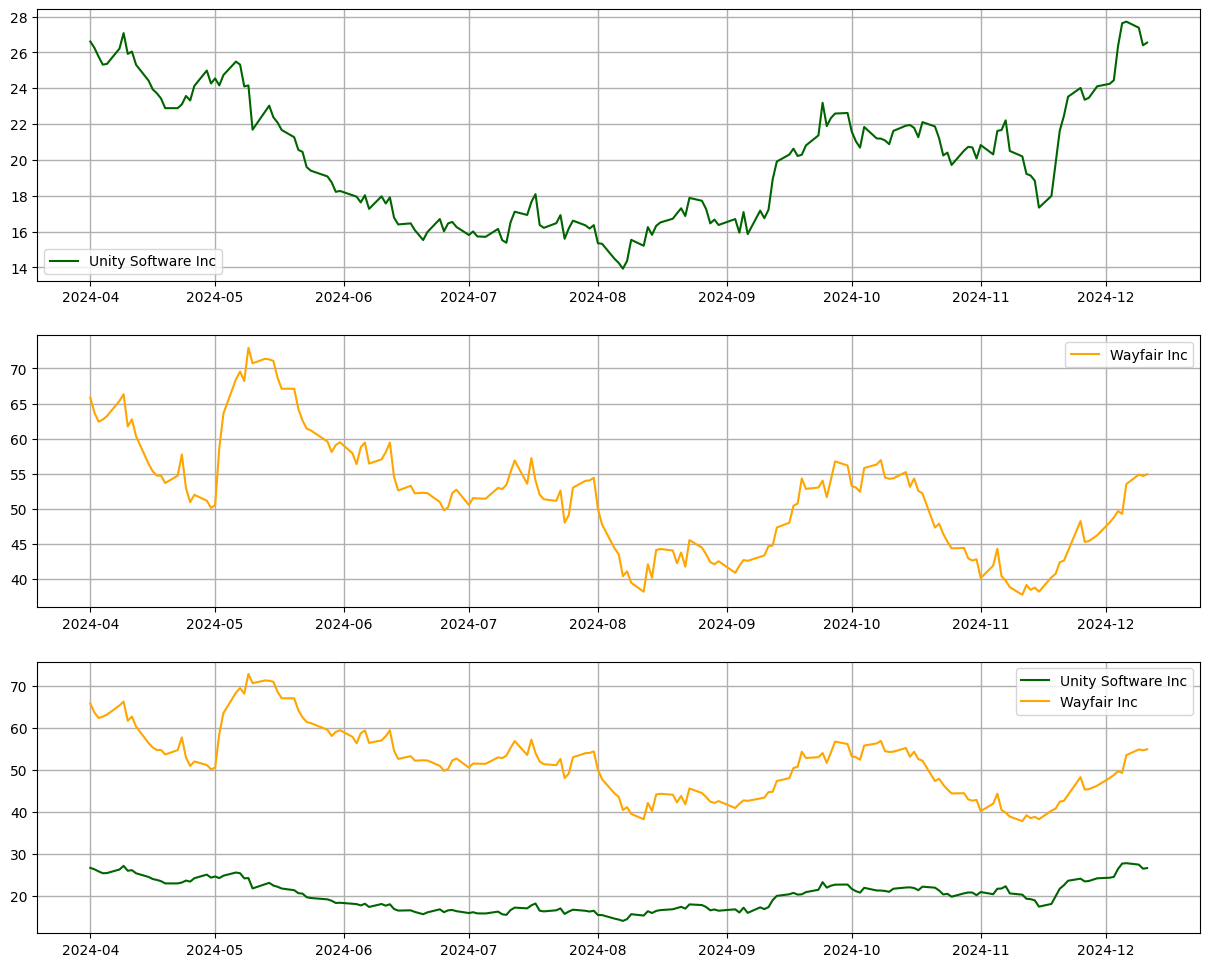

In [ ]:
fig = plt.figure(figsize=(15, 12))
ax = fig.subplots(3,1)

ax[0].plot(test_data.dataframe[u], color="darkgreen", label="Unity Software Inc")
ax[0].grid(True, which='both', linewidth=1)
# ax[0].minorticks_on()
ax[0].legend()

ax[1].plot(test_data.dataframe[w], color="orange", label="Wayfair Inc")
ax[1].grid(True, which='both', linewidth=1)
# ax[1].minorticks_on()
ax[1].legend()

ax[2].plot(test_data.dataframe[u], color="darkgreen", label="Unity Software Inc")
ax[2].plot(test_data.dataframe[w], color="orange", label="Wayfair Inc")
ax[2].grid(True, which='both', linewidth=1)
# ax[2].minorticks_on()
ax[2].legend()

### Линейная регрессия

$$ y_i ≈ \sum_{j=0}^m {β_j \times x^i_j}$$


$$\vec \beta = (X^{T}X)^{-1}X^TY $$

In [ ]:
class LinearRegression:
    def __init__(self):
        self.p = 0
        self.parameters = 0
        self.x_matrix = 0
        self.y_matrix = 0
        self.arr_len = 0

    def train(self, x:pd.Series, y:pd.Series):
        self.p = 1
        self.x_matrix = x.to_numpy()
        self.x_matrix = np.c_[np.ones(len(y)), self.x_matrix]
        self.y_matrix = y.to_numpy()
        self.arr_len = len(y)
        self.parameters = np.dot(np.linalg.inv(np.dot(self.x_matrix.T, self.x_matrix)), np.dot(self.x_matrix.T, self.y_matrix))
        return self

    def predict(self, x:pd.DataFrame):
        x_predict = np.c_[np.ones(len(x)), x.to_numpy()]
        return np.dot(x_predict, self.parameters)

In [ ]:
def split_data(data:pd.DataFrame, target_name: str):
    features = data.drop(target_name, axis=1)
    target = data[target_name]
    return features, target


In [ ]:
features, target = split_data(train_data.dataframe, u)
test_features, test_target = split_data(test_data.dataframe, u)

In [ ]:
model = LinearRegression()
model.train(features[w], target)
predicted_name = "Predicted"
my_prediction = model.predict(test_data.dataframe[w])

In [ ]:
from sklearn.linear_model import LinearRegression as LibLinearRegression
libraryModel = LibLinearRegression().fit(features, target)
libraryPrediction = libraryModel.predict(test_features)
lib_predicted_name = "lib_predicted"
lib_prediction = libraryPrediction

In [ ]:
test_data.dataframe[lib_predicted_name] = lib_prediction
test_data.dataframe[predicted_name] = my_prediction

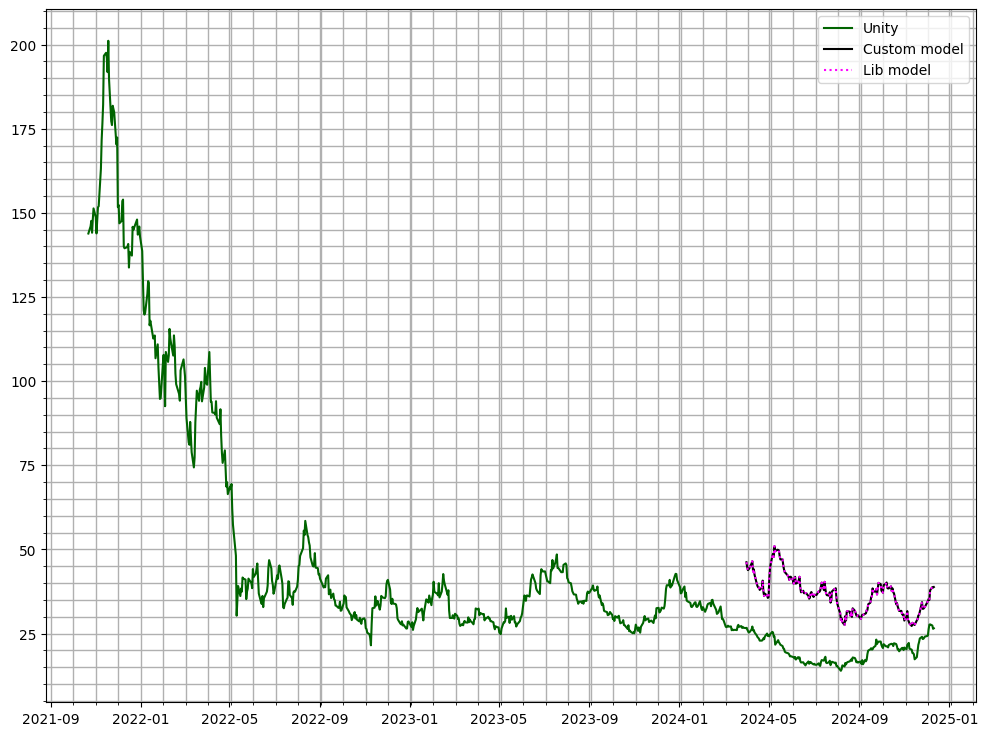

In [ ]:
fig = plt.figure(figsize=(12, 9))
ax = fig.subplots(1,1)

ax.plot(train_data.dataframe[u], color="darkgreen", label="Unity")
ax.plot(test_data.dataframe[u], color="darkgreen")
ax.plot(test_data.dataframe[predicted_name], color="black",  label="Custom model")
ax.plot(test_data.dataframe[lib_predicted_name], color="magenta", linestyle=':', label="Lib model")
ax.grid(True, which='both', linewidth=1)
ax.minorticks_on()
ax.legend()

### Автокорреляционный анализ

In [ ]:
unity_array = np.concatenate((train_data.dataframe[u].to_numpy(), test_data.dataframe[u].to_numpy()), axis=None)

In [ ]:
def autocorrealtion(array, start, finish):
  correlations = {}
  for step_size in range(start, finish):
    sections = len(array) // step_size
    start_array = array[:step_size]
    start_array_subtract_mean = start_array - start_array.mean()
    correlations_by_step = []
    for step_num in range(1, sections):
      step_array = array[step_size*step_num:step_size*(step_num+1)]
      step_array_substract_mean = step_array - step_array.mean()
      coef = np.sum(start_array_subtract_mean * step_array_substract_mean) / mh.sqrt(np.sum(start_array_subtract_mean**2) * np.sum(step_array_substract_mean**2))
      correlations_by_step.append(coef)
    correlations[step_size] = (sum(correlations_by_step)/len(correlations_by_step))
  return correlations

In [ ]:
half_num = len(unity_array)//2
coefs = autocorrealtion(unity_array, 3, half_num + 1)

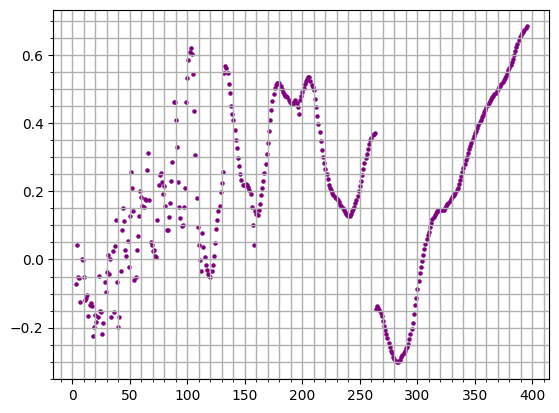

In [ ]:
plt.scatter(coefs.keys(), coefs.values(), color="purple", s=5)
plt.grid(True, which='both', linewidth=1)
plt.minorticks_on()

In [ ]:
print(f"Maксимальный коэффициент корреляции {max(coefs.values())}, N = {half_num} (половина длины последовательности)")

Maксимальный коэффициент корреляции 0.6839281525601487, N = 395 (половина длины последовательности)
